# ***Wine Quality Classification Analysis***

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ***Preprocessing***

In [25]:
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

In [26]:
train_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [27]:
test_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Untuk melihat 5 baris teratas dalam setiap dataset untuk melihat gambaran isi setiap dataset, terutama nama kolomnya apakah sudah benar dan sesuai.

In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [29]:
print(train_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [30]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


In [31]:
print(test_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Untuk melihat ringkasan teknis dari dataset, seperti nama kolom, jumlah data, ada data yang kosong atau tidak, tipe data. Terlihat bahwa tidak ada satupun kolom pada dataset train maupun test yang kosong.

In [32]:
X = train_df.drop(['quality', 'Id'], axis=1)
y = train_df['quality']

X_test_final = test_df.drop(['Id'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_final_scaled = scaler.transform(X_test_final)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

1. Untuk menghilangkan kolom Id dan quality pada 'X' karena Id tidak ada hubungannya dengan rasa anggur, dan quality adalah kunci jawaban yang tidak boleh dicontek model saat belajar. Dan mengambil kolom quality untuk dipelajari model sebagai "target" atau jawaban benar pada 'y'.

2. Untuk membuang kolom Id-nya agar jumlah kolomnya sama persis dengan 'X' yang dipelajari model tadi.

3. Untuk menyamakan skala data sehingga semua fitur punya pengaruh yang adil bagi model.

4. Untuk membagi data agar dapat melakukan simulasi awal.

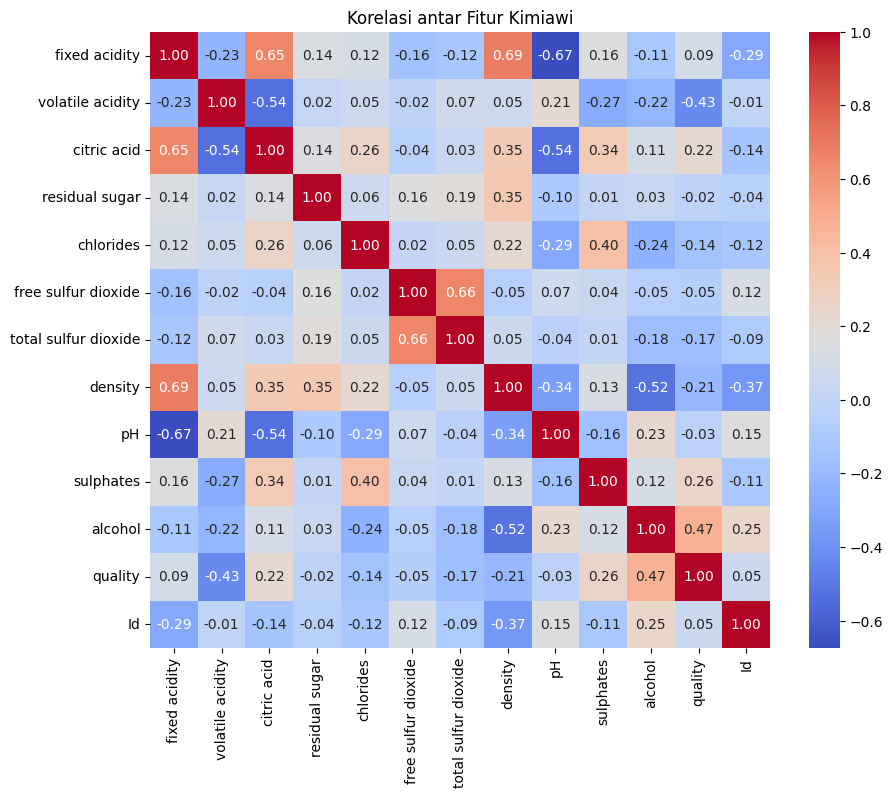

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antar Fitur Kimiawi')
plt.show()

Untuk memberitahu seberapa kuat hubungan antara satu fitur (misal: Alkohol) dengan fitur lainnya atau dengan target (quality). Semakin merah maka Korelasi Positif Kuat. Artinya, jika nilai fitur A naik, maka nilai kualitas anggur juga cenderung naik. Sebaliknya, Semakin biru maka Korelasi Negatif Kuat. Artinya, jika nilai fitur A naik, maka nilai kualitas anggur juga cenderung turun.

Berdasarkan Heatmap di atas, pada kolom quality dapat terlihat yang memperngaruhi naiknya kualitas wine adalah alcohol dan yang mempengaruhi turunnya kualitas wine adalah volatile acidity.

# **Perbandingan Model**

Untuk menguji dan membandingkan beberapa algoritma klasifikasi untuk menemukan model yang paling akurat dalam memprediksi kualitas wine. Model yang diuji meliputi Random Forest, Gradient Boosting, SMV, KNN, Decision Tree, Logistic Regression, dan Ensemble.

# ***Random Forest***

In [34]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)

print("\n--- Evaluasi Model ---")
print(f"Accuracy Score: {accuracy_score(y_val, y_pred_val)}")


--- Evaluasi Model ---
Accuracy Score: 0.5813953488372093


# ***Gradient Boosting***

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_val)
print(f"Akurasi Gradient Boosting: {accuracy_score(y_val, y_pred_gb)}")

Akurasi Gradient Boosting: 0.6453488372093024


# **SVM**

In [36]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)
print(f"Akurasi SVM: {accuracy_score(y_val, y_pred_svm)}")

Akurasi SVM: 0.5697674418604651


# **KNN**

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)
print(f"Akurasi KNN: {accuracy_score(y_val, y_pred_knn)}")

Akurasi KNN: 0.5058139534883721


# ***Decision Tree***

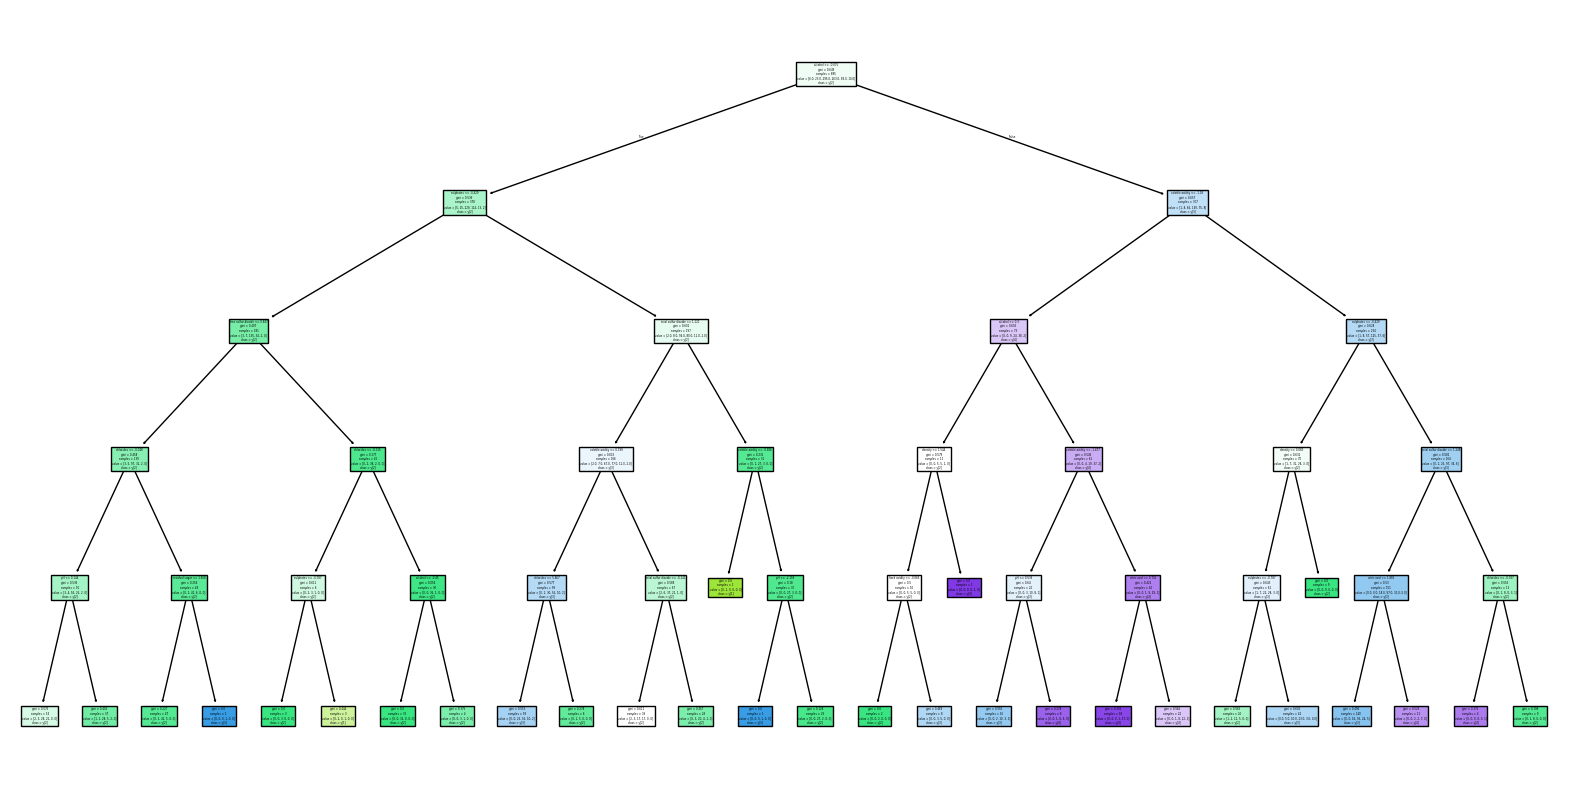

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=True, filled=True)
plt.show()

In [39]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

print(f"Akurasi Decision Tree: {accuracy_score(y_val, y_pred_dt)}")

Akurasi Decision Tree: 0.563953488372093


# ***Logistic Regression***

In [40]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_val)
print(f"Akurasi Logistic Regression: {accuracy_score(y_val, y_pred_log)}")

Akurasi Logistic Regression: 0.5988372093023255


# ***ENSEMBLE***

In [41]:
from sklearn.ensemble import VotingClassifier
clf1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2 = GradientBoostingClassifier(random_state=42)
clf3 = SVC(probability=True, random_state=42)

voting_model = VotingClassifier(
    estimators=[('rf', clf1), ('gb', clf2), ('svc', clf3)],
    voting='soft'
)

voting_model.fit(X_train, y_train)
print(f"Akurasi Voting Model: {accuracy_score(y_val, voting_model.predict(X_val))}")

Akurasi Voting Model: 0.6511627906976745


# **Ringkasan Perbandingan Model & Visualisasinya**

Untuk melihat perbandingan secara ringkas dan lebih jelas dari model yang telah di uji.

In [42]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Voting Ensemble":  VotingClassifier(
        estimators=[('rf', clf1), ('gb', clf2), ('svc', clf3)],
        voting='soft'
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    accuracy = accuracy_score(y_val, predictions)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

df_comparison = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
df_comparison = df_comparison.sort_values(by='Accuracy', ascending=False)

Random Forest Accuracy: 0.5814
Gradient Boosting Accuracy: 0.6453
SVM Accuracy: 0.5698
KNN Accuracy: 0.5058
Decision Tree Accuracy: 0.5640
Logistic Regression Accuracy: 0.5988
Voting Ensemble Accuracy: 0.6512


/tmp/ipykernel_12735/395458318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_comparison, palette='viridis')


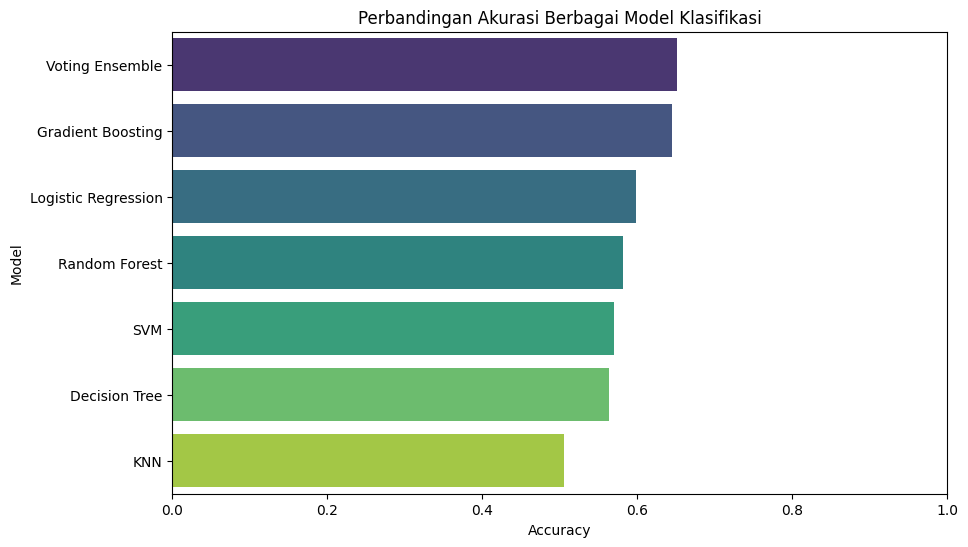

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_comparison, palette='viridis')
plt.title('Perbandingan Akurasi Berbagai Model Klasifikasi')
plt.xlim(0, 1.0)
plt.show()

Berdasarkan perbandingan model di atas, yang dapat di ketahui:

1. model Ensemble (Voting Classifier) memberikan akurasi tertinggi sebesar 0.6512. Model ini mengungguli model tunggal lainnya.
2. model Gradient Boosting dan Random Forest memiliki akurasi yang lebih tinggi dibandingkan model linear seperti Logistic Regression. Hal ini menunjukkan bahwa hubungan antar fitur kimiawi anggur cenderung bersifat non-linear. Artinya, kualitas wine tidak ditentukan secara linear oleh satu atau dua fitur saja, melainkan melalui interaksi kompleks antar berbagai fitur kimiawi. Algoritma berbasis pohon (tree-based) lebih mampu menangkap pola interaksi dan ambang batas (threshold) tertentu yang gagal ditangkap oleh model linear.
3. rata-rata akurasi berada di angka 50%-65%, mengindikasikan adanya ambiguitas pada label kualitas 5 dan 6 yang memiliki kemiripan fitur kimiawi tinggi.

# **Hasil Presiksi**

Model final yang digunakan adalah Voting Classifier dengan pendekatan Ensemble Learning. Model ini mengintegrasikan tiga algoritma berbeda (Gradient Boosting, Random Forest, dan SVM) untuk bekerja sama. Dengan menggunakan metode 'soft voting', model mengambil keputusan berdasarkan rata-rata probabilitas tertinggi dari ketiga kontributor tersebut. Strategi ini diambil untuk menutupi kelemahan masing-masing model tunggal dan memberikan hasil prediksi kualitas wine yang lebih stabil dan akurat pada data testing.

In [44]:
from sklearn.ensemble import VotingClassifier

clf1 = GradientBoostingClassifier(random_state=42)
clf2 = RandomForestClassifier(random_state=42)
clf3 = SVC(probability=True, random_state=42)

ensemble_final = VotingClassifier(
    estimators=[('gb', clf1), ('rf', clf2), ('svc', clf3)],
    voting='soft'
)

ensemble_final.fit(X_scaled, y)

VotingClassifier(estimators=[('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [45]:
final_predictions = ensemble_final.predict(X_test_final_scaled)

Tahap implementasi model Ensemble pada data pengujian (data_testing.csv). Model melakukan prediksi kualitas anggur terhadap X_test_final_scaled yang telah melalui proses standarisasi

In [46]:
df_hasil = pd.DataFrame({
    'Id': test_df['Id'],
    'Quality': final_predictions
})

df_hasil.to_csv('hasilprediksi_112.csv', index=False)

print("File prediksi berhasil dibuat!")

File prediksi berhasil dibuat!


Tahap terakhir adalah menyusun hasil prediksi ke dalam format DataFrame yang terdiri dari kolom Id dan Quality. Data tersebut kemudian diekspor ke dalam file CSV sesuai dengan ketentuan tugas. File ini berisi jawaban final dari model Ensemble yang siap untuk dikumpulkan dan dievaluasi performanya.